In [69]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, countDistinct, avg, desc, asc,
    regexp_replace, round, when, to_date,
    max as spark_max
 )

spark = SparkSession.builder \
    .appName("Lab4 Airbnb Team16 Spark DataFrame Analysis") \
    .master("spark://spark-master:7077") \
    .config("spark.executor.memory", "4g") \
    .config("spark.executor.cores", "2") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.range(10).show()

+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
|  5|
|  6|
|  7|
|  8|
|  9|
+---+



In [70]:
import os

BASE_PATH = "/home/ubuntu/airbnb-spark-lab/data/raw"
OUTPUT_TABLE_PATH = "/home/ubuntu/airbnb-spark-lab/outputs/tables"
OUTPUT_CHART_PATH = "/home/ubuntu/airbnb-spark-lab/outputs/charts"

os.makedirs(OUTPUT_TABLE_PATH, exist_ok=True)
os.makedirs(OUTPUT_CHART_PATH, exist_ok=True)

print("Base path:", BASE_PATH)
print("Output table path:", OUTPUT_TABLE_PATH)
print("Output chart path:", OUTPUT_CHART_PATH)

Base path: /home/ubuntu/airbnb-spark-lab/data/raw
Output table path: /home/ubuntu/airbnb-spark-lab/outputs/tables
Output chart path: /home/ubuntu/airbnb-spark-lab/outputs/charts


In [71]:
listings = spark.read.csv(
    f"{BASE_PATH}/listings.csv.gz",
    header=True,
    inferSchema=True,
    multiLine=True,
    escape='"'
)

calendar = spark.read.csv(
    f"{BASE_PATH}/calendar.csv.gz",
    header=True,
    inferSchema=True,
    multiLine=True,
    escape='"'
)

reviews = spark.read.csv(
    f"{BASE_PATH}/reviews.csv.gz",
    header=True,
    inferSchema=True,
    multiLine=True,
    escape='"'
)

neighbourhoods = spark.read.csv(
    f"{BASE_PATH}/neighbourhoods.csv",
    header=True,
    inferSchema=True
)

print("Listings:", listings.count())
print("Calendar:", calendar.count())
print("Reviews:", reviews.count())
print("Neighbourhoods:", neighbourhoods.count())

Listings: 600
Calendar: 219000
Reviews: 48913
Neighbourhoods: 1


In [72]:
listings.show(5, truncate=False)

+-------+------------------------------------+--------------+------------+-----------+-----------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [73]:
listings.show(5, truncate=False)

+-------+------------------------------------+--------------+------------+-----------+-----------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [74]:
calendar.show(5, truncate=False)

+----------+----------+---------+-----+--------------+--------------+--------------+
|listing_id|date      |available|price|adjusted_price|minimum_nights|maximum_nights|
+----------+----------+---------+-----+--------------+--------------+--------------+
|13747912  |2025-11-12|f        |NULL |NULL          |1             |14            |
|13747912  |2025-11-13|t        |NULL |NULL          |1             |14            |
|13747912  |2025-11-14|f        |NULL |NULL          |1             |14            |
|13747912  |2025-11-15|f        |NULL |NULL          |1             |14            |
|13747912  |2025-11-16|t        |NULL |NULL          |1             |14            |
+----------+----------+---------+-----+--------------+--------------+--------------+
only showing top 5 rows



In [75]:
reviews.show(5, truncate=False)

+----------+-------+----------+-----------+-------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|listing_id|id     |date      |reviewer_id|reviewer_name|comments                                                                                                                                                                                                                                                                                                                                                                                                           |
+----------+-------+----------+-----------+-------------+-------------------

In [76]:
listings.printSchema()

root
 |-- id: long (nullable = true)
 |-- listing_url: string (nullable = true)
 |-- scrape_id: long (nullable = true)
 |-- last_scraped: date (nullable = true)
 |-- source: string (nullable = true)
 |-- name: string (nullable = true)
 |-- description: string (nullable = true)
 |-- neighborhood_overview: string (nullable = true)
 |-- picture_url: string (nullable = true)
 |-- host_id: integer (nullable = true)
 |-- host_url: string (nullable = true)
 |-- host_name: string (nullable = true)
 |-- host_since: date (nullable = true)
 |-- host_location: string (nullable = true)
 |-- host_about: string (nullable = true)
 |-- host_response_time: string (nullable = true)
 |-- host_response_rate: string (nullable = true)
 |-- host_acceptance_rate: string (nullable = true)
 |-- host_is_superhost: string (nullable = true)
 |-- host_thumbnail_url: string (nullable = true)
 |-- host_picture_url: string (nullable = true)
 |-- host_neighbourhood: string (nullable = true)
 |-- host_listings_count: int

In [77]:
listings.printSchema()

root
 |-- id: long (nullable = true)
 |-- listing_url: string (nullable = true)
 |-- scrape_id: long (nullable = true)
 |-- last_scraped: date (nullable = true)
 |-- source: string (nullable = true)
 |-- name: string (nullable = true)
 |-- description: string (nullable = true)
 |-- neighborhood_overview: string (nullable = true)
 |-- picture_url: string (nullable = true)
 |-- host_id: integer (nullable = true)
 |-- host_url: string (nullable = true)
 |-- host_name: string (nullable = true)
 |-- host_since: date (nullable = true)
 |-- host_location: string (nullable = true)
 |-- host_about: string (nullable = true)
 |-- host_response_time: string (nullable = true)
 |-- host_response_rate: string (nullable = true)
 |-- host_acceptance_rate: string (nullable = true)
 |-- host_is_superhost: string (nullable = true)
 |-- host_thumbnail_url: string (nullable = true)
 |-- host_picture_url: string (nullable = true)
 |-- host_neighbourhood: string (nullable = true)
 |-- host_listings_count: int

In [78]:
listings.printSchema()

root
 |-- id: long (nullable = true)
 |-- listing_url: string (nullable = true)
 |-- scrape_id: long (nullable = true)
 |-- last_scraped: date (nullable = true)
 |-- source: string (nullable = true)
 |-- name: string (nullable = true)
 |-- description: string (nullable = true)
 |-- neighborhood_overview: string (nullable = true)
 |-- picture_url: string (nullable = true)
 |-- host_id: integer (nullable = true)
 |-- host_url: string (nullable = true)
 |-- host_name: string (nullable = true)
 |-- host_since: date (nullable = true)
 |-- host_location: string (nullable = true)
 |-- host_about: string (nullable = true)
 |-- host_response_time: string (nullable = true)
 |-- host_response_rate: string (nullable = true)
 |-- host_acceptance_rate: string (nullable = true)
 |-- host_is_superhost: string (nullable = true)
 |-- host_thumbnail_url: string (nullable = true)
 |-- host_picture_url: string (nullable = true)
 |-- host_neighbourhood: string (nullable = true)
 |-- host_listings_count: int

In [79]:
null_report = []

for c in listings_clean.columns:
    null_count = listings_clean.where(col(c).isNull()).count()
    null_report.append((c, null_count))

null_df = spark.createDataFrame(null_report, ["column_name", "null_count"])
null_df.orderBy(desc("null_count")).show(30)

+--------------------+----------+
|         column_name|null_count|
+--------------------+----------+
|neighbourhood_gro...|       547|
|review_scores_rating|        77|
|            bedrooms|         2|
|            latitude|         0|
|      minimum_nights|         0|
|           longitude|         0|
|           host_name|         0|
|       property_type|         0|
|      maximum_nights|         0|
|                beds|         0|
|    availability_365|         0|
|neighbourhood_cle...|         0|
|   number_of_reviews|         0|
|           room_type|         0|
|calculated_host_l...|         0|
|                  id|         0|
|        accommodates|         0|
|               price|         0|
|                name|         0|
|         price_clean|         0|
|             host_id|         0|
+--------------------+----------+



In [80]:
listings_clean = listings.withColumn(
    "price_clean",
    regexp_replace(col("price"), "[$,]", "").cast("double")
)

important_cols = [
    "id",
    "name",
    "host_id",
    "host_name",
    "neighbourhood_group_cleansed",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "property_type",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "price",
    "price_clean",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "calculated_host_listings_count"
]

existing_cols = [c for c in important_cols if c in listings_clean.columns]
listings_clean = listings_clean.select(*existing_cols)

listings_clean.show(5, truncate=False)

+-------+-----------------------------------+-------+--------------+----------------------------+----------------------+--------+----------+------------------+---------------+------------+--------+----+-------+-----------+--------------+--------------+----------------+-----------------+--------------------+------------------------------+
|id     |name                               |host_id|host_name     |neighbourhood_group_cleansed|neighbourhood_cleansed|latitude|longitude |property_type     |room_type      |accommodates|bedrooms|beds|price  |price_clean|minimum_nights|maximum_nights|availability_365|number_of_reviews|review_scores_rating|calculated_host_listings_count|
+-------+-----------------------------------+-------+--------------+----------------------------+----------------------+--------+----------+------------------+---------------+------------+--------+----+-------+-----------+--------------+--------------+----------------+-----------------+--------------------+------------

In [81]:
null_report = []

for c in listings_clean.columns:
    null_count = listings_clean.where(col(c).isNull()).count()
    null_report.append((c, null_count))

null_df = spark.createDataFrame(null_report, ["column_name", "null_count"])
null_df.orderBy(desc("null_count")).show(30)

+--------------------+----------+
|         column_name|null_count|
+--------------------+----------+
|neighbourhood_gro...|       600|
|review_scores_rating|        84|
|                beds|        53|
|               price|        53|
|         price_clean|        53|
|            bedrooms|         4|
|            latitude|         0|
|      minimum_nights|         0|
|           longitude|         0|
|                  id|         0|
|       property_type|         0|
|      maximum_nights|         0|
|           room_type|         0|
|    availability_365|         0|
|           host_name|         0|
|   number_of_reviews|         0|
|        accommodates|         0|
|calculated_host_l...|         0|
|                name|         0|
|neighbourhood_cle...|         0|
|             host_id|         0|
+--------------------+----------+



In [82]:
listings_clean = listings_clean.where(col("price_clean").isNotNull())

print("Listings after removing missing price:", listings_clean.count())

Listings after removing missing price: 547


In [88]:
if "neighbourhood_group_cleansed" in listings_clean.columns and listings_clean.filter(col("neighbourhood_group_cleansed").isNotNull()).limit(1).count() > 0:
    region_col = "neighbourhood_group_cleansed"
else:
    region_col = "neighbourhood_cleansed"

print("Using region column:", region_col)

Using region column: neighbourhood_cleansed


In [90]:
host_listing_count = listings_clean.groupBy("host_id", "host_name") \
    .agg(count("*").alias("listing_count")) \
    .orderBy(desc("listing_count"))

host_listing_count.show(20, truncate=False)

+---------+----------------------+-------------+
|host_id  |host_name             |listing_count|
+---------+----------------------+-------------+
|158595657|Mountain Home         |40           |
|87300632 |Liz                   |28           |
|8224408  |Paul                  |17           |
|69417001 |Louisa                |14           |
|441896318|Payton                |11           |
|22366054 |Tessa                 |10           |
|78849013 |Stay Montana          |9            |
|122381278|Evolve                |8            |
|169754903|VR Bozeman            |8            |
|10719166 |Ted And Ann Marie     |8            |
|521636962|Jacob                 |8            |
|430914923|Residence Inn Bozeman |6            |
|657455752|Aishat                |6            |
|68940904 |The Arrival           |5            |
|49746531 |Nina                  |5            |
|166104792|Caleb Joshua          |4            |
|388858579|Neil                  |4            |
|406871   |Erin     

In [86]:
if "calculated_host_listings_count" in listings_clean.columns:
    listings_clean.select(
        spark_max("calculated_host_listings_count").alias("max_calculated_host_listings_count")
    ).show()

+----------------------------------+
|max_calculated_host_listings_count|
+----------------------------------+
|                                41|
+----------------------------------+



In [91]:
region_count = listings_clean.groupBy(region_col) \
    .agg(count("*").alias("listing_count")) \
    .orderBy(desc("listing_count"))

region_count.show()

+----------------------+-------------+
|neighbourhood_cleansed|listing_count|
+----------------------+-------------+
|               Bozeman|          547|
+----------------------+-------------+



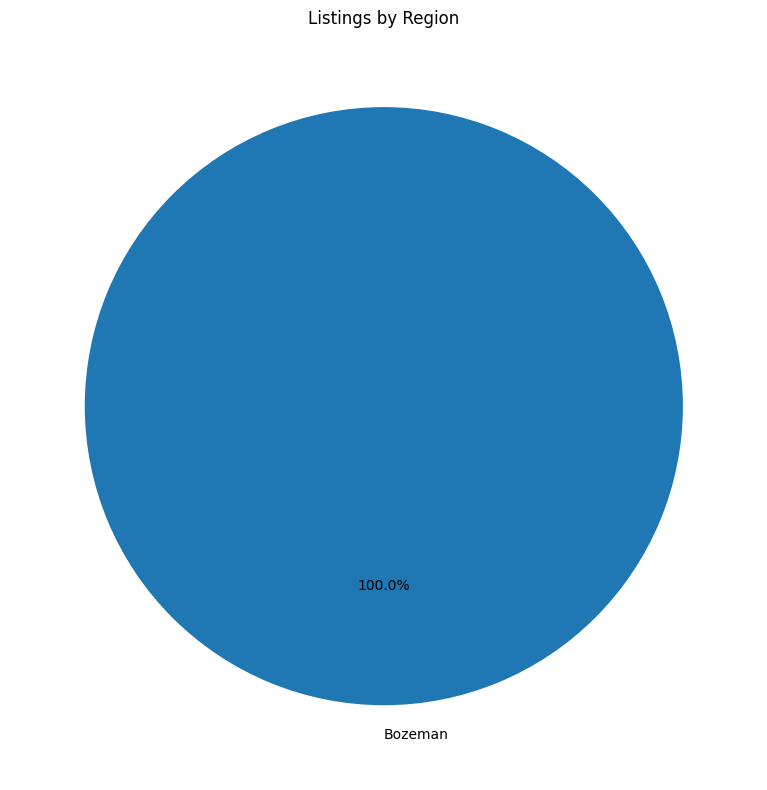

In [92]:
import matplotlib.pyplot as plt

region_pd = region_count.toPandas()

plt.figure(figsize=(8, 8))
plt.pie(
    region_pd["listing_count"],
    labels=region_pd[region_col],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Listings by Region")
plt.tight_layout()
plt.savefig(f"{OUTPUT_CHART_PATH}/listings_by_region.png")
plt.show()

In [93]:
room_type_count = listings_clean.groupBy("room_type") \
    .agg(count("*").alias("listing_count")) \
    .orderBy(desc("listing_count"))

room_type_count.show()

+---------------+-------------+
|      room_type|listing_count|
+---------------+-------------+
|Entire home/apt|          484|
|   Private room|           52|
|     Hotel room|            8|
|    Shared room|            3|
+---------------+-------------+



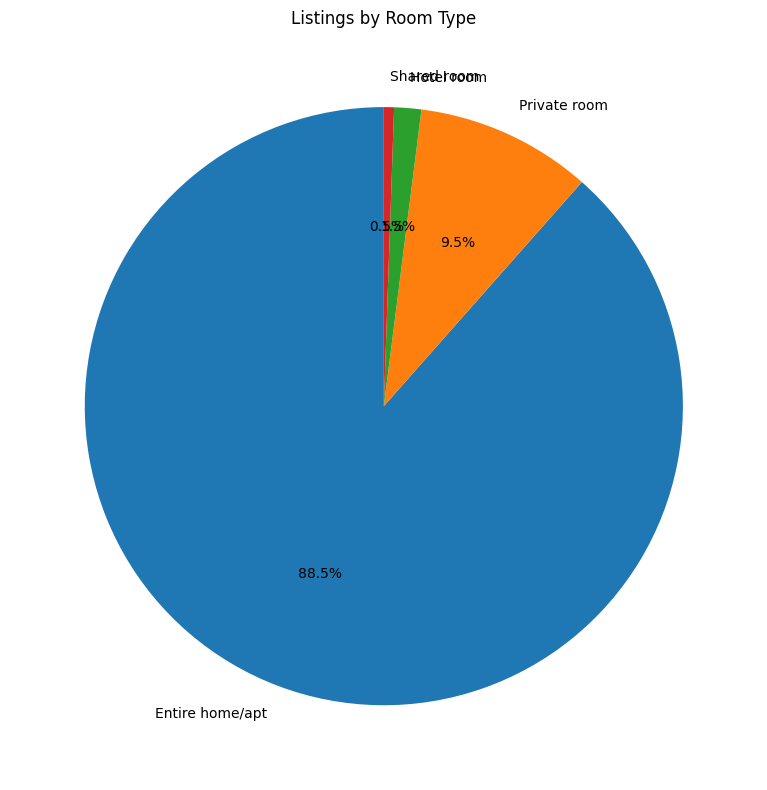

In [94]:
room_pd = room_type_count.toPandas()

plt.figure(figsize=(8, 8))
plt.pie(
    room_pd["listing_count"],
    labels=room_pd["room_type"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Listings by Room Type")
plt.tight_layout()
plt.savefig(f"{OUTPUT_CHART_PATH}/listings_by_room_type.png")
plt.show()

In [95]:
room_by_region = listings_clean.groupBy(region_col, "room_type") \
    .agg(count("*").alias("listing_count")) \
    .orderBy(region_col, desc("listing_count"))

room_by_region.show(50)

+----------------------+---------------+-------------+
|neighbourhood_cleansed|      room_type|listing_count|
+----------------------+---------------+-------------+
|               Bozeman|Entire home/apt|          484|
|               Bozeman|   Private room|           52|
|               Bozeman|     Hotel room|            8|
|               Bozeman|    Shared room|            3|
+----------------------+---------------+-------------+



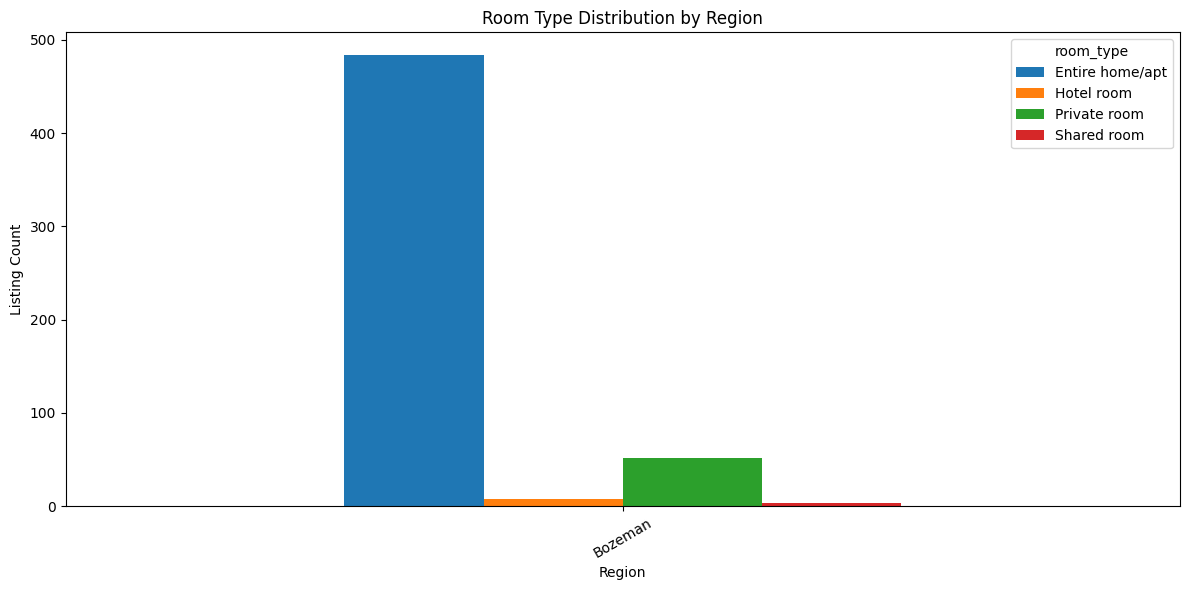

In [96]:
room_region_pd = room_by_region.toPandas()

pivot_room_region = room_region_pd.pivot(
    index=region_col,
    columns="room_type",
    values="listing_count"
).fillna(0)

pivot_room_region.plot(kind="bar", figsize=(12, 6))
plt.title("Room Type Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Listing Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{OUTPUT_CHART_PATH}/room_type_by_region.png")
plt.show()

In [97]:
avg_price_by_region_room = listings_clean.groupBy(region_col, "room_type") \
    .agg(
        count("*").alias("listing_count"),
        round(avg("price_clean"), 2).alias("avg_price")
    ) \
    .orderBy(region_col, desc("avg_price"))

avg_price_by_region_room.show(50)

+----------------------+---------------+-------------+---------+
|neighbourhood_cleansed|      room_type|listing_count|avg_price|
+----------------------+---------------+-------------+---------+
|               Bozeman|     Hotel room|            8|  11317.5|
|               Bozeman|Entire home/apt|          484|   205.58|
|               Bozeman|   Private room|           52|   117.29|
|               Bozeman|    Shared room|            3|    33.33|
+----------------------+---------------+-------------+---------+



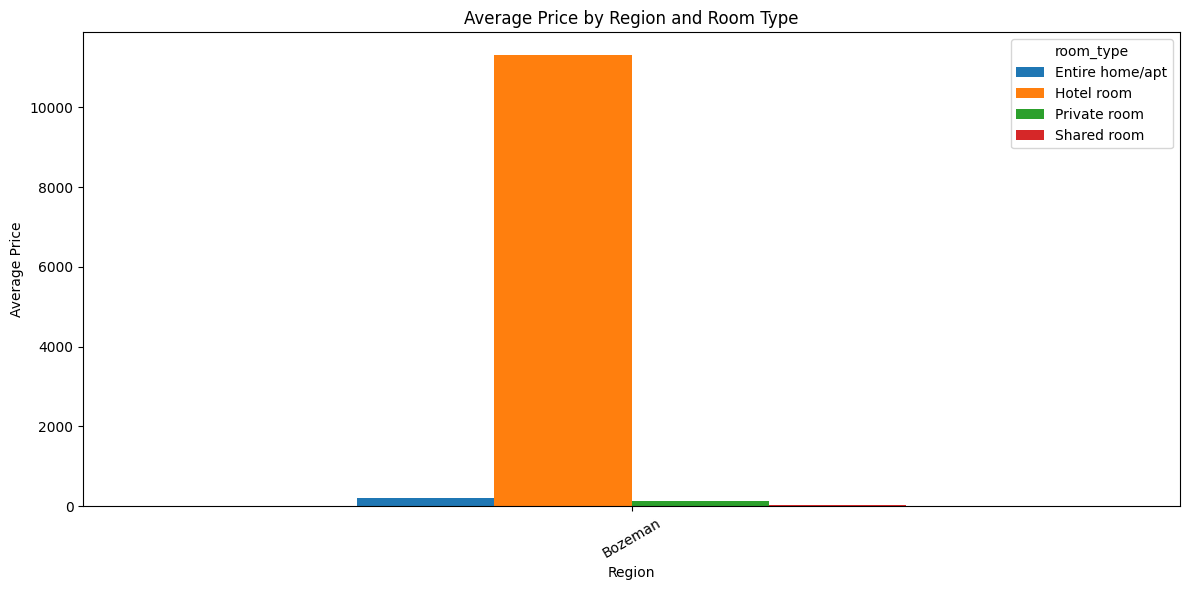

In [98]:
price_region_pd = avg_price_by_region_room.toPandas()

pivot_price_region = price_region_pd.pivot(
    index=region_col,
    columns="room_type",
    values="avg_price"
).fillna(0)

pivot_price_region.plot(kind="bar", figsize=(12, 6))
plt.title("Average Price by Region and Room Type")
plt.xlabel("Region")
plt.ylabel("Average Price")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{OUTPUT_CHART_PATH}/avg_price_by_region_room_type.png")
plt.show()

In [99]:
top_neighbourhoods = listings_clean.groupBy("neighbourhood_cleansed") \
    .agg(count("*").alias("listing_count")) \
    .orderBy(desc("listing_count")) \
    .limit(10)

top_neighbourhoods.show()

+----------------------+-------------+
|neighbourhood_cleansed|listing_count|
+----------------------+-------------+
|               Bozeman|          547|
+----------------------+-------------+



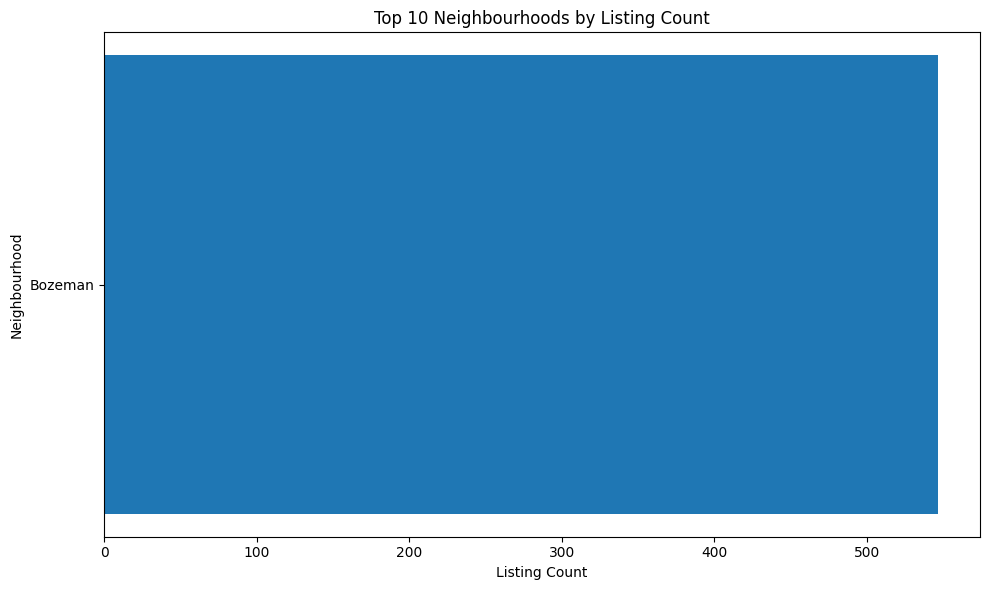

In [100]:
top_neighbourhoods_pd = top_neighbourhoods.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(
    top_neighbourhoods_pd["neighbourhood_cleansed"],
    top_neighbourhoods_pd["listing_count"]
)
plt.title("Top 10 Neighbourhoods by Listing Count")
plt.xlabel("Listing Count")
plt.ylabel("Neighbourhood")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{OUTPUT_CHART_PATH}/top_neighbourhoods.png")
plt.show()

In [101]:
minimum_nights_dist = listings_clean.groupBy("minimum_nights") \
    .agg(count("*").alias("listing_count")) \
    .orderBy(asc("minimum_nights"))

minimum_nights_dist.show(30)

+--------------+-------------+
|minimum_nights|listing_count|
+--------------+-------------+
|             1|          174|
|             2|          151|
|             3|           67|
|             4|            6|
|             5|            2|
|            27|           22|
|            28|           27|
|            29|            1|
|            30|           91|
|            31|            2|
|            60|            1|
|            90|            2|
|           180|            1|
+--------------+-------------+



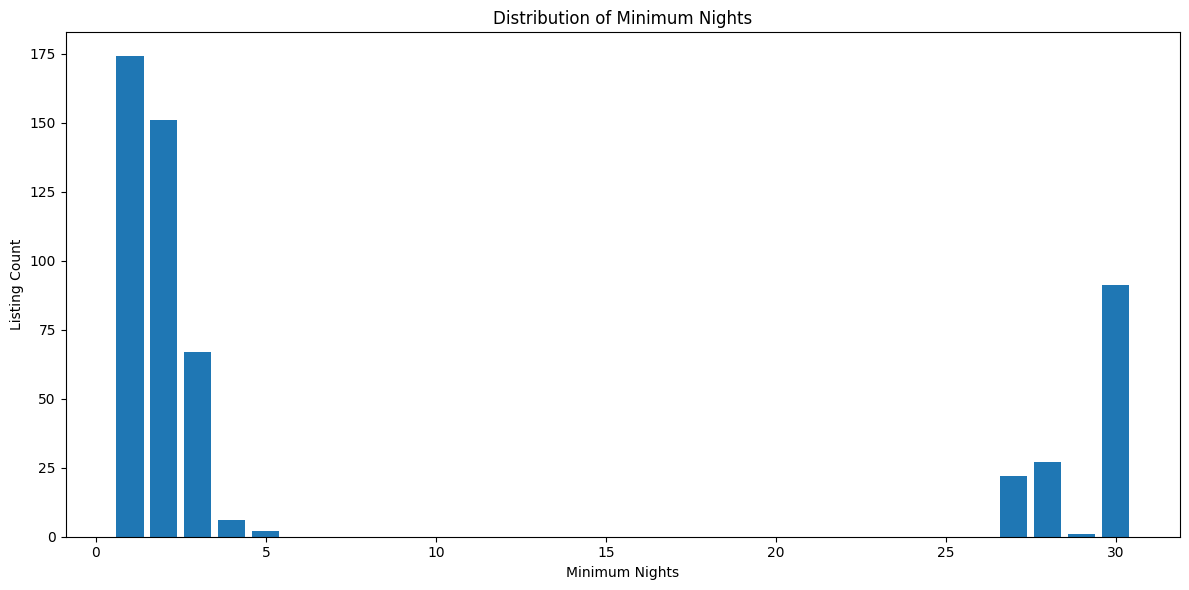

In [102]:
min_nights_30 = minimum_nights_dist.where(col("minimum_nights") <= 30)
min_nights_pd = min_nights_30.toPandas()

plt.figure(figsize=(12, 6))
plt.bar(min_nights_pd["minimum_nights"], min_nights_pd["listing_count"])
plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Listing Count")
plt.tight_layout()
plt.savefig(f"{OUTPUT_CHART_PATH}/minimum_nights_distribution.png")
plt.show()

In [103]:
popular_listings = listings_clean.select(
    "id",
    "name",
    "host_name",
    "neighbourhood_cleansed",
    "room_type",
    "price_clean",
    "number_of_reviews",
    "review_scores_rating"
).orderBy(desc("number_of_reviews"))

popular_listings.show(20, truncate=False)

+--------+-------------------------------------------------+------------+----------------------+---------------+-----------+-----------------+--------------------+
|id      |name                                             |host_name   |neighbourhood_cleansed|room_type      |price_clean|number_of_reviews|review_scores_rating|
+--------+-------------------------------------------------+------------+----------------------+---------------+-----------+-----------------+--------------------+
|8471627 |Downtown Digs (3 blocks from the center of DT)   |Jade        |Bozeman               |Entire home/apt|149.0      |849              |4.94                |
|18509621|The Attic Downtown - Walk to Main Street!        |Hilary      |Bozeman               |Entire home/apt|127.0      |781              |4.89                |
|20468639|Your Adventure and Downtown Base-Camp            |Donald      |Bozeman               |Private room   |76.0       |738              |4.77                |
|21563216|Cozy a

In [104]:
calendar_clean = calendar.withColumn(
    "calendar_price_clean",
    regexp_replace(col("price"), "[$,]", "").cast("double")
).withColumn(
    "is_available",
    when(col("available") == "t", 1).otherwise(0)
).withColumn(
    "date",
    to_date(col("date"))
)

calendar_clean.select(
    "listing_id", "date", "available", "is_available", "calendar_price_clean"
).show(10)

+----------+----------+---------+------------+--------------------+
|listing_id|      date|available|is_available|calendar_price_clean|
+----------+----------+---------+------------+--------------------+
|  13747912|2025-11-12|        f|           0|                NULL|
|  13747912|2025-11-13|        t|           1|                NULL|
|  13747912|2025-11-14|        f|           0|                NULL|
|  13747912|2025-11-15|        f|           0|                NULL|
|  13747912|2025-11-16|        t|           1|                NULL|
|  13747912|2025-11-17|        t|           1|                NULL|
|  13747912|2025-11-18|        t|           1|                NULL|
|  13747912|2025-11-19|        t|           1|                NULL|
|  13747912|2025-11-20|        t|           1|                NULL|
|  13747912|2025-11-21|        f|           0|                NULL|
+----------+----------+---------+------------+--------------------+
only showing top 10 rows



In [105]:
daily_availability = calendar_clean.groupBy("date") \
    .agg(
        count("*").alias("calendar_records"),
        round(avg("is_available"), 4).alias("availability_rate"),
        round(avg("calendar_price_clean"), 2).alias("avg_calendar_price")
    ) \
    .orderBy("date")

daily_availability.show(20)

+----------+----------------+-----------------+------------------+
|      date|calendar_records|availability_rate|avg_calendar_price|
+----------+----------------+-----------------+------------------+
|2025-11-12|             600|           0.4167|              NULL|
|2025-11-13|             600|            0.435|              NULL|
|2025-11-14|             600|           0.4633|              NULL|
|2025-11-15|             600|             0.45|              NULL|
|2025-11-16|             600|             0.57|              NULL|
|2025-11-17|             600|           0.6083|              NULL|
|2025-11-18|             600|           0.6217|              NULL|
|2025-11-19|             600|           0.6133|              NULL|
|2025-11-20|             600|           0.6083|              NULL|
|2025-11-21|             600|           0.5717|              NULL|
|2025-11-22|             600|             0.54|              NULL|
|2025-11-23|             600|           0.5567|              N

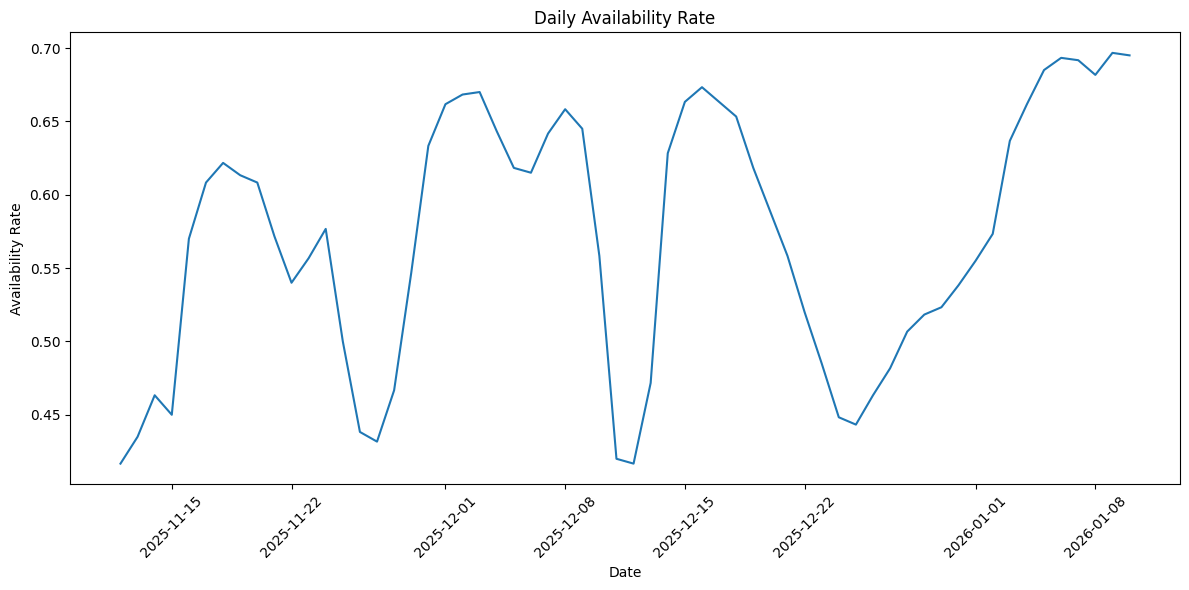

In [106]:
daily_availability_pd = daily_availability.limit(60).toPandas()

plt.figure(figsize=(12, 6))
plt.plot(
    daily_availability_pd["date"],
    daily_availability_pd["availability_rate"]
)
plt.title("Daily Availability Rate")
plt.xlabel("Date")
plt.ylabel("Availability Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_CHART_PATH}/daily_availability_rate.png")
plt.show()

In [107]:
reviews_clean = reviews.withColumn(
    "date",
    to_date(col("date"))
)

reviews_clean.show(5, truncate=False)

+----------+-------+----------+-----------+-------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|listing_id|id     |date      |reviewer_id|reviewer_name|comments                                                                                                                                                                                                                                                                                                                                                                                                           |
+----------+-------+----------+-----------+-------------+-------------------

In [108]:
review_count_by_listing = reviews_clean.groupBy("listing_id") \
    .agg(count("*").alias("actual_review_count"))

review_count_by_listing.show(10)

+-------------------+-------------------+
|         listing_id|actual_review_count|
+-------------------+-------------------+
|           43745220|                  2|
|           50675728|                108|
| 744478255073405873|                176|
|            9740033|                 98|
|           45075319|                515|
| 675168752481235212|                 88|
|1108037590849320235|                 19|
|1040565103561819864|                109|
|1314082323149340257|                 21|
|           25580821|                 98|
+-------------------+-------------------+
only showing top 10 rows



In [109]:
listing_review_join = listings_clean.join(
    review_count_by_listing,
    listings_clean.id == review_count_by_listing.listing_id,
    "left"
).select(
    listings_clean.id,
    "name",
    "room_type",
    "neighbourhood_cleansed",
    "price_clean",
    "number_of_reviews",
    "actual_review_count"
)

listing_review_join.orderBy(desc("actual_review_count")).show(20, truncate=False)

+--------+-------------------------------------------------+---------------+----------------------+-----------+-----------------+-------------------+
|id      |name                                             |room_type      |neighbourhood_cleansed|price_clean|number_of_reviews|actual_review_count|
+--------+-------------------------------------------------+---------------+----------------------+-----------+-----------------+-------------------+
|8471627 |Downtown Digs (3 blocks from the center of DT)   |Entire home/apt|Bozeman               |149.0      |849              |849                |
|18509621|The Attic Downtown - Walk to Main Street!        |Entire home/apt|Bozeman               |127.0      |781              |781                |
|20468639|Your Adventure and Downtown Base-Camp            |Private room   |Bozeman               |76.0       |738              |738                |
|21563216|Cozy and Clean Apartment in Downtown Bozeman     |Entire home/apt|Bozeman               |8

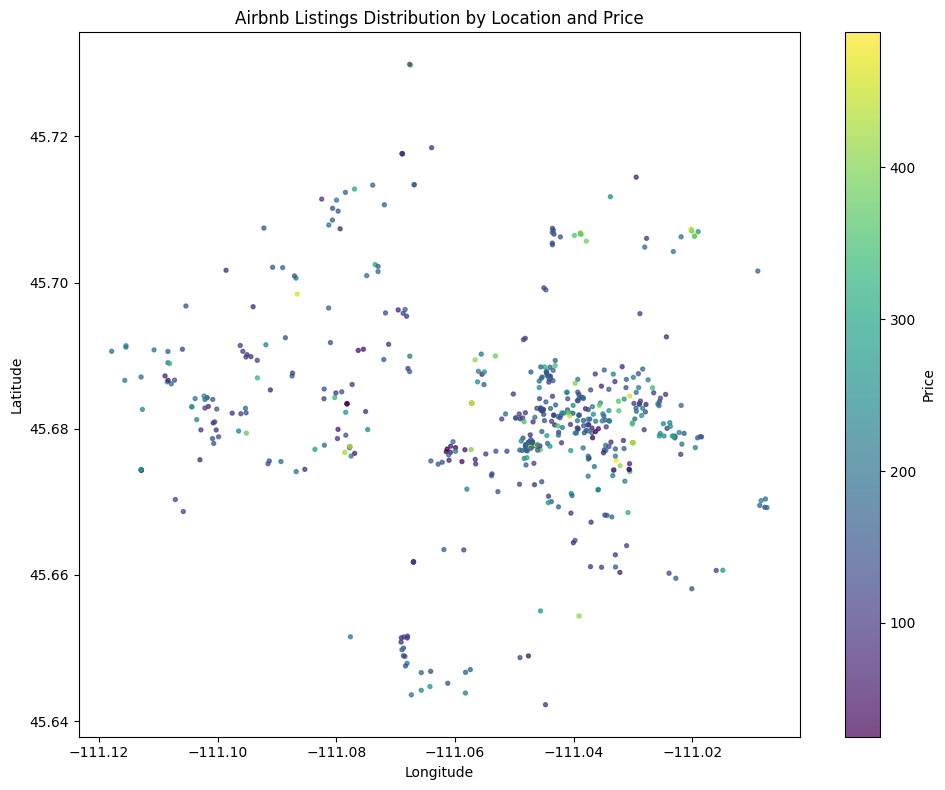

In [110]:
geo_df = listings_clean.select(
    "latitude",
    "longitude",
    "price_clean",
    region_col,
    "room_type"
).where(
    col("latitude").isNotNull() &
    col("longitude").isNotNull() &
    col("price_clean").isNotNull()
)

geo_df_filtered = geo_df.where(col("price_clean") <= 500)
geo_pd = geo_df_filtered.toPandas()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    geo_pd["longitude"],
    geo_pd["latitude"],
    c=geo_pd["price_clean"],
    s=8,
    alpha=0.7
)
plt.colorbar(scatter, label="Price")
plt.title("Airbnb Listings Distribution by Location and Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig(f"{OUTPUT_CHART_PATH}/listing_location_price_scatter.png")
plt.show()

In [111]:
host_listing_count.coalesce(1).write.mode("overwrite").option("header", True).csv(
    f"{OUTPUT_TABLE_PATH}/host_listing_count"
)

region_count.coalesce(1).write.mode("overwrite").option("header", True).csv(
    f"{OUTPUT_TABLE_PATH}/region_count"
)

room_type_count.coalesce(1).write.mode("overwrite").option("header", True).csv(
    f"{OUTPUT_TABLE_PATH}/room_type_count"
)

room_by_region.coalesce(1).write.mode("overwrite").option("header", True).csv(
    f"{OUTPUT_TABLE_PATH}/room_by_region"
)

avg_price_by_region_room.coalesce(1).write.mode("overwrite").option("header", True).csv(
    f"{OUTPUT_TABLE_PATH}/avg_price_by_region_room"
)

top_neighbourhoods.coalesce(1).write.mode("overwrite").option("header", True).csv(
    f"{OUTPUT_TABLE_PATH}/top_neighbourhoods"
)

minimum_nights_dist.coalesce(1).write.mode("overwrite").option("header", True).csv(
    f"{OUTPUT_TABLE_PATH}/minimum_nights_distribution"
)

popular_listings.coalesce(1).write.mode("overwrite").option("header", True).csv(
    f"{OUTPUT_TABLE_PATH}/popular_listings"
)

daily_availability.coalesce(1).write.mode("overwrite").option("header", True).csv(
    f"{OUTPUT_TABLE_PATH}/daily_availability"
)

listing_review_join.coalesce(1).write.mode("overwrite").option("header", True).csv(
    f"{OUTPUT_TABLE_PATH}/listing_review_join"
)

print("All output tables saved successfully.")

All output tables saved successfully.


In [112]:
import os

print("Charts:")
for f in os.listdir(OUTPUT_CHART_PATH):
    print("-", f)

print("\nTables:")
for f in os.listdir(OUTPUT_TABLE_PATH):
    print("-", f)

Charts:
- daily_availability_rate.png
- room_type_by_region.png
- listings_by_region.png
- listing_location_price_scatter.png
- avg_price_by_region_room_type.png
- top_neighbourhoods.png
- minimum_nights_distribution.png
- listings_by_room_type.png

Tables:
- popular_listings
- room_type_count
- host_listing_count
- room_by_region
- top_neighbourhoods
- region_count
- minimum_nights_distribution
- avg_price_by_region_room
- listing_review_join
- daily_availability


In [113]:
print("Lab 4 Airbnb Team16 analysis completed.")
print("Main completed tasks:")
print("1. Connected to Spark cluster.")
print("2. Loaded 4 Airbnb datasets.")
print("3. Inspected schema and sample records.")
print("4. Cleaned price and missing values.")
print("5. Analyzed host concentration.")
print("6. Analyzed listing distribution by region.")
print("7. Analyzed listing distribution by room type.")
print("8. Analyzed room type distribution by region.")
print("9. Analyzed average price by region and room type.")
print("10. Analyzed top neighbourhoods.")
print("11. Analyzed minimum nights.")
print("12. Analyzed popular listings by reviews.")
print("13. Analyzed calendar availability.")
print("14. Joined listings and reviews datasets.")
print("15. Visualized location and price distribution.")
print("16. Saved output tables and charts.")

Lab 4 Airbnb Team16 analysis completed.
Main completed tasks:
1. Connected to Spark cluster.
2. Loaded 4 Airbnb datasets.
3. Inspected schema and sample records.
4. Cleaned price and missing values.
5. Analyzed host concentration.
6. Analyzed listing distribution by region.
7. Analyzed listing distribution by room type.
8. Analyzed room type distribution by region.
9. Analyzed average price by region and room type.
10. Analyzed top neighbourhoods.
11. Analyzed minimum nights.
12. Analyzed popular listings by reviews.
13. Analyzed calendar availability.
14. Joined listings and reviews datasets.
15. Visualized location and price distribution.
16. Saved output tables and charts.
